# Tutorial : Quality control of localizations with `trace_anlyzer` and filtering with `trace_filter`

## Objective
More user-provided quality thresholds can be used with `trace_filter` to filter spots with insights from the localizations table quality control analysis.

`localization_analyzer` loads one localization table and generates a quality-control summary plot for the detected barcode localizations.


## Input
Localization tables with snr, intensity, etc. columns (pyHiM format) `localizations_3D_barcode.dat`

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC"
dest_path = f"{data_path}/output"

input_localization = f"{data_path}/localizations_3D_barcode_version_0.dat"
input_trace = f"{data_path}/Trace_3D_barcode_KDtree_ROI-22.ecsv"

print(f"Input file: {input_localization}")
print(f"Output: {dest_path}")


Input file: /mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/localizations_3D_barcode_version_0.dat
Output: /mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/output


## Step 1: Run Quality Control Analysis


In [13]:
output = f"{dest_path}/distribution_statistics.png"
!localization_analyzer --localization_file {input_localization} -o {output}

------- Running localization_analyzer.py --------
Load a localization table and plot localization quality-control distributions.

Input parameters
---------------
localization_file-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/localizations_3D_barcode_version_0.dat
output_file-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/output/distribution_statistics.png
format-->png
Finished execution


### Display localization distribution


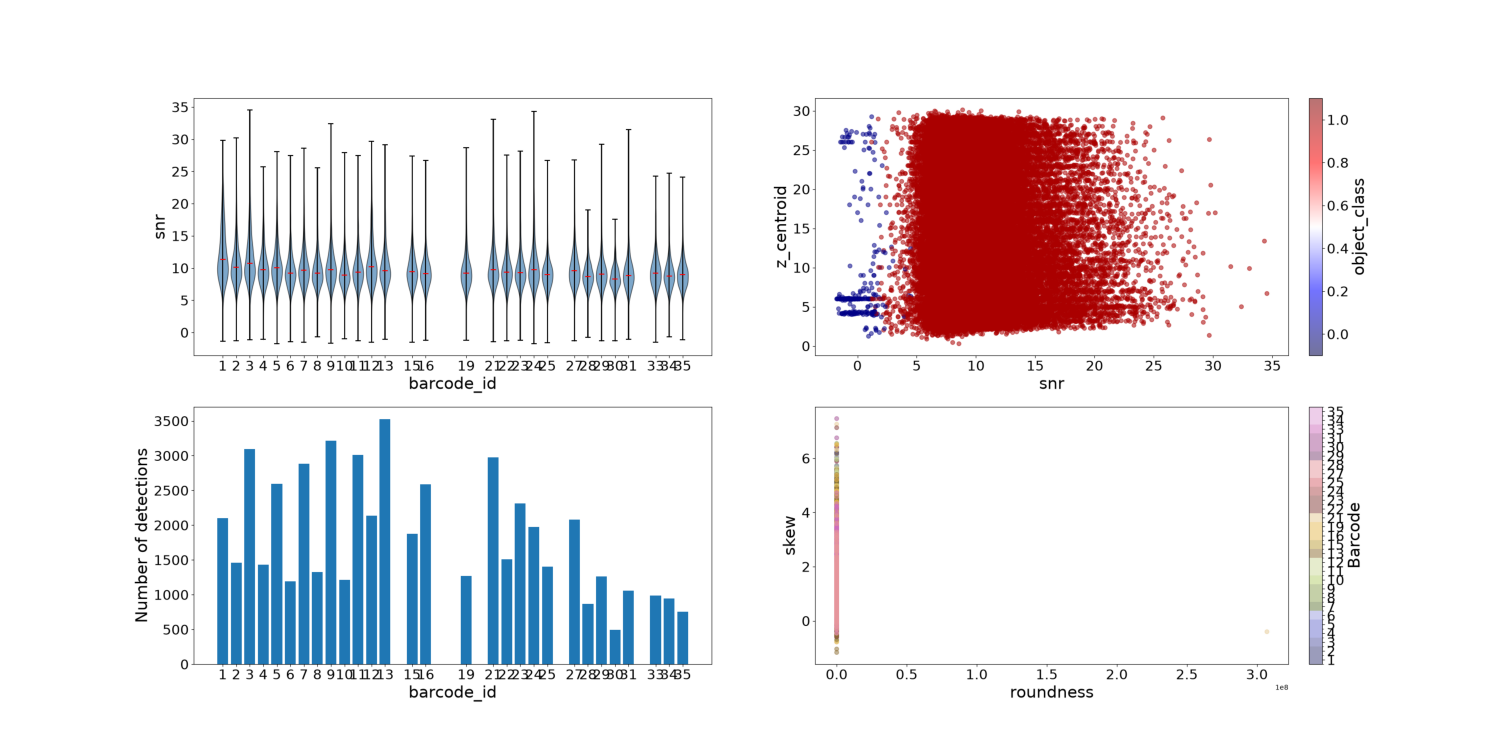

In [14]:
# Display the localization_distribution plots
img = mpimg.imread(f"{dest_path}/distribution_statistics.png")
fig, ax = plt.subplots(figsize=(15, 15))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

Comments on graphic

> **Note:**

## Step 2 : Using localization QC insights to filter traces

`trace_filter` has multiple options of filters that can be adjusted with the plots from the quality control analysis above.


### Example 1 : Filtering SNR 
From the previous plot above we can decide to filter SNR > 5 .

In [22]:
!trace_filter --input {input_trace} --localization_file {input_localization} --snr_min 5 -O filtered

------- Running trace_filter.py --------
Filter chromatin trace files.

==========Started execution==========

$ trace files to process: ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv']

$ trace files to process= ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv']
$ Loaded localizations table with: 53519 rows
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv

$ Filtering duplicated barcodes

$ Filtering barcodes based on coordinates

$ Filtering barcodes based on localization quality
> Removed 0/22866 localizations outside localization quality thresholds (snr>=5.0).
> Number of rows in filtered trace table: 22866

$ Filtering barcode number

$ Removing traces with < 2 spots
$ Number of original spots / traces: 22866 / 8921
$ Analyzing traces...
$ Number of traces to rem

You can add several thresholds filter at once
```bash
trace_filter \
  --input Trace.ecsv \
  --localization_file Localizations.ecsv \
  --intensity_min 1000 \
  --snr_min 5 \
  --object_class_min 1 \
  --spot_pixel_percentage_max 0.7 \
  --roundness_max 0.8
```

### Example 2 : Filter intensities 
We can also filter localizations based on intensity.

In [18]:
!trace_filter --input {input_trace} --localization_file {input_localization} --intensity_min 1000 -O filtered

------- Running trace_filter.py --------
Filter chromatin trace files.

==========Started execution==========

$ trace files to process: ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv']

$ trace files to process= ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv']
$ Loaded localizations table with: 53519 rows
$ Saved intensity distribution plot as /mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/localizations_3D_barcode_version_0_localization_intensities.png
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv

$ Filtering duplicated barcodes

$ Filtering barcodes based on coordinates

$ Filtering barcodes based on localization quality
> Removed 18291/22866 localizations outside localization quality thresholds (mean_intensity>=1000.0).
> Number of rows in filt

### Example 2 : Filter roundness and skew


In [23]:
!trace_filter --input {input_trace} --localization_file {input_localization} --skew_min 1 --roundness_max 2 --snr_min 5 --intensity_min 1000 -O filtered

------- Running trace_filter.py --------
Filter chromatin trace files.

==========Started execution==========

$ trace files to process: ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv']

$ trace files to process= ['/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv']
$ Loaded localizations table with: 53519 rows
$ Saved intensity distribution plot as /mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/localizations_3D_barcode_version_0_localization_intensities.png
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22.ecsv

$ Filtering duplicated barcodes

$ Filtering barcodes based on coordinates

$ Filtering barcodes based on localization quality
> Removed 18425/22866 localizations outside localization quality thresholds (snr>=5.0, skew>=1.0, mean_intensity>=1000.0, roun

### Display intensities before and after filtering

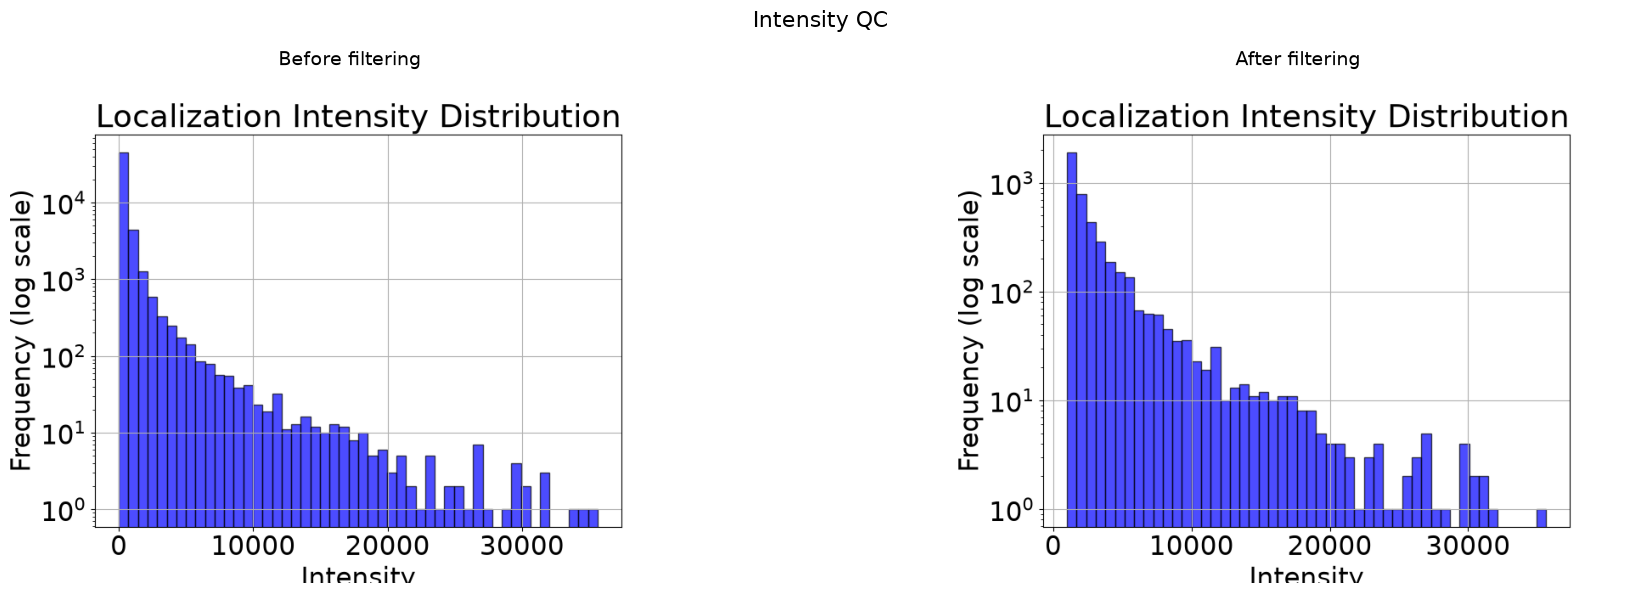

In [24]:
before = f"{data_path}/localizations_3D_barcode_version_0_localization_intensities.png"
after = f"{data_path}/Trace_3D_barcode_KDtree_ROI-22_filtered_intensities.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before, after],
                         ["Before filtering",
                          "After filtering"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Intensity QC ", fontsize=16)
plt.tight_layout()
plt.show()

### Step 3 : Check QC after filtering

In [25]:
localizations = f"{data_path}/Trace_3D_barcode_KDtree_ROI-22_filtered_localizations.ecsv" 
!localization_analyzer --localization_file {localizations}

------- Running localization_analyzer.py --------
Load a localization table and plot localization quality-control distributions.

Input parameters
---------------
localization_file-->/mnt/grey/DATA/users/zidoum/traceraptops/data/Localization_QC/Trace_3D_barcode_KDtree_ROI-22_filtered_localizations.ecsv
output_file-->None
format-->png
Finished execution


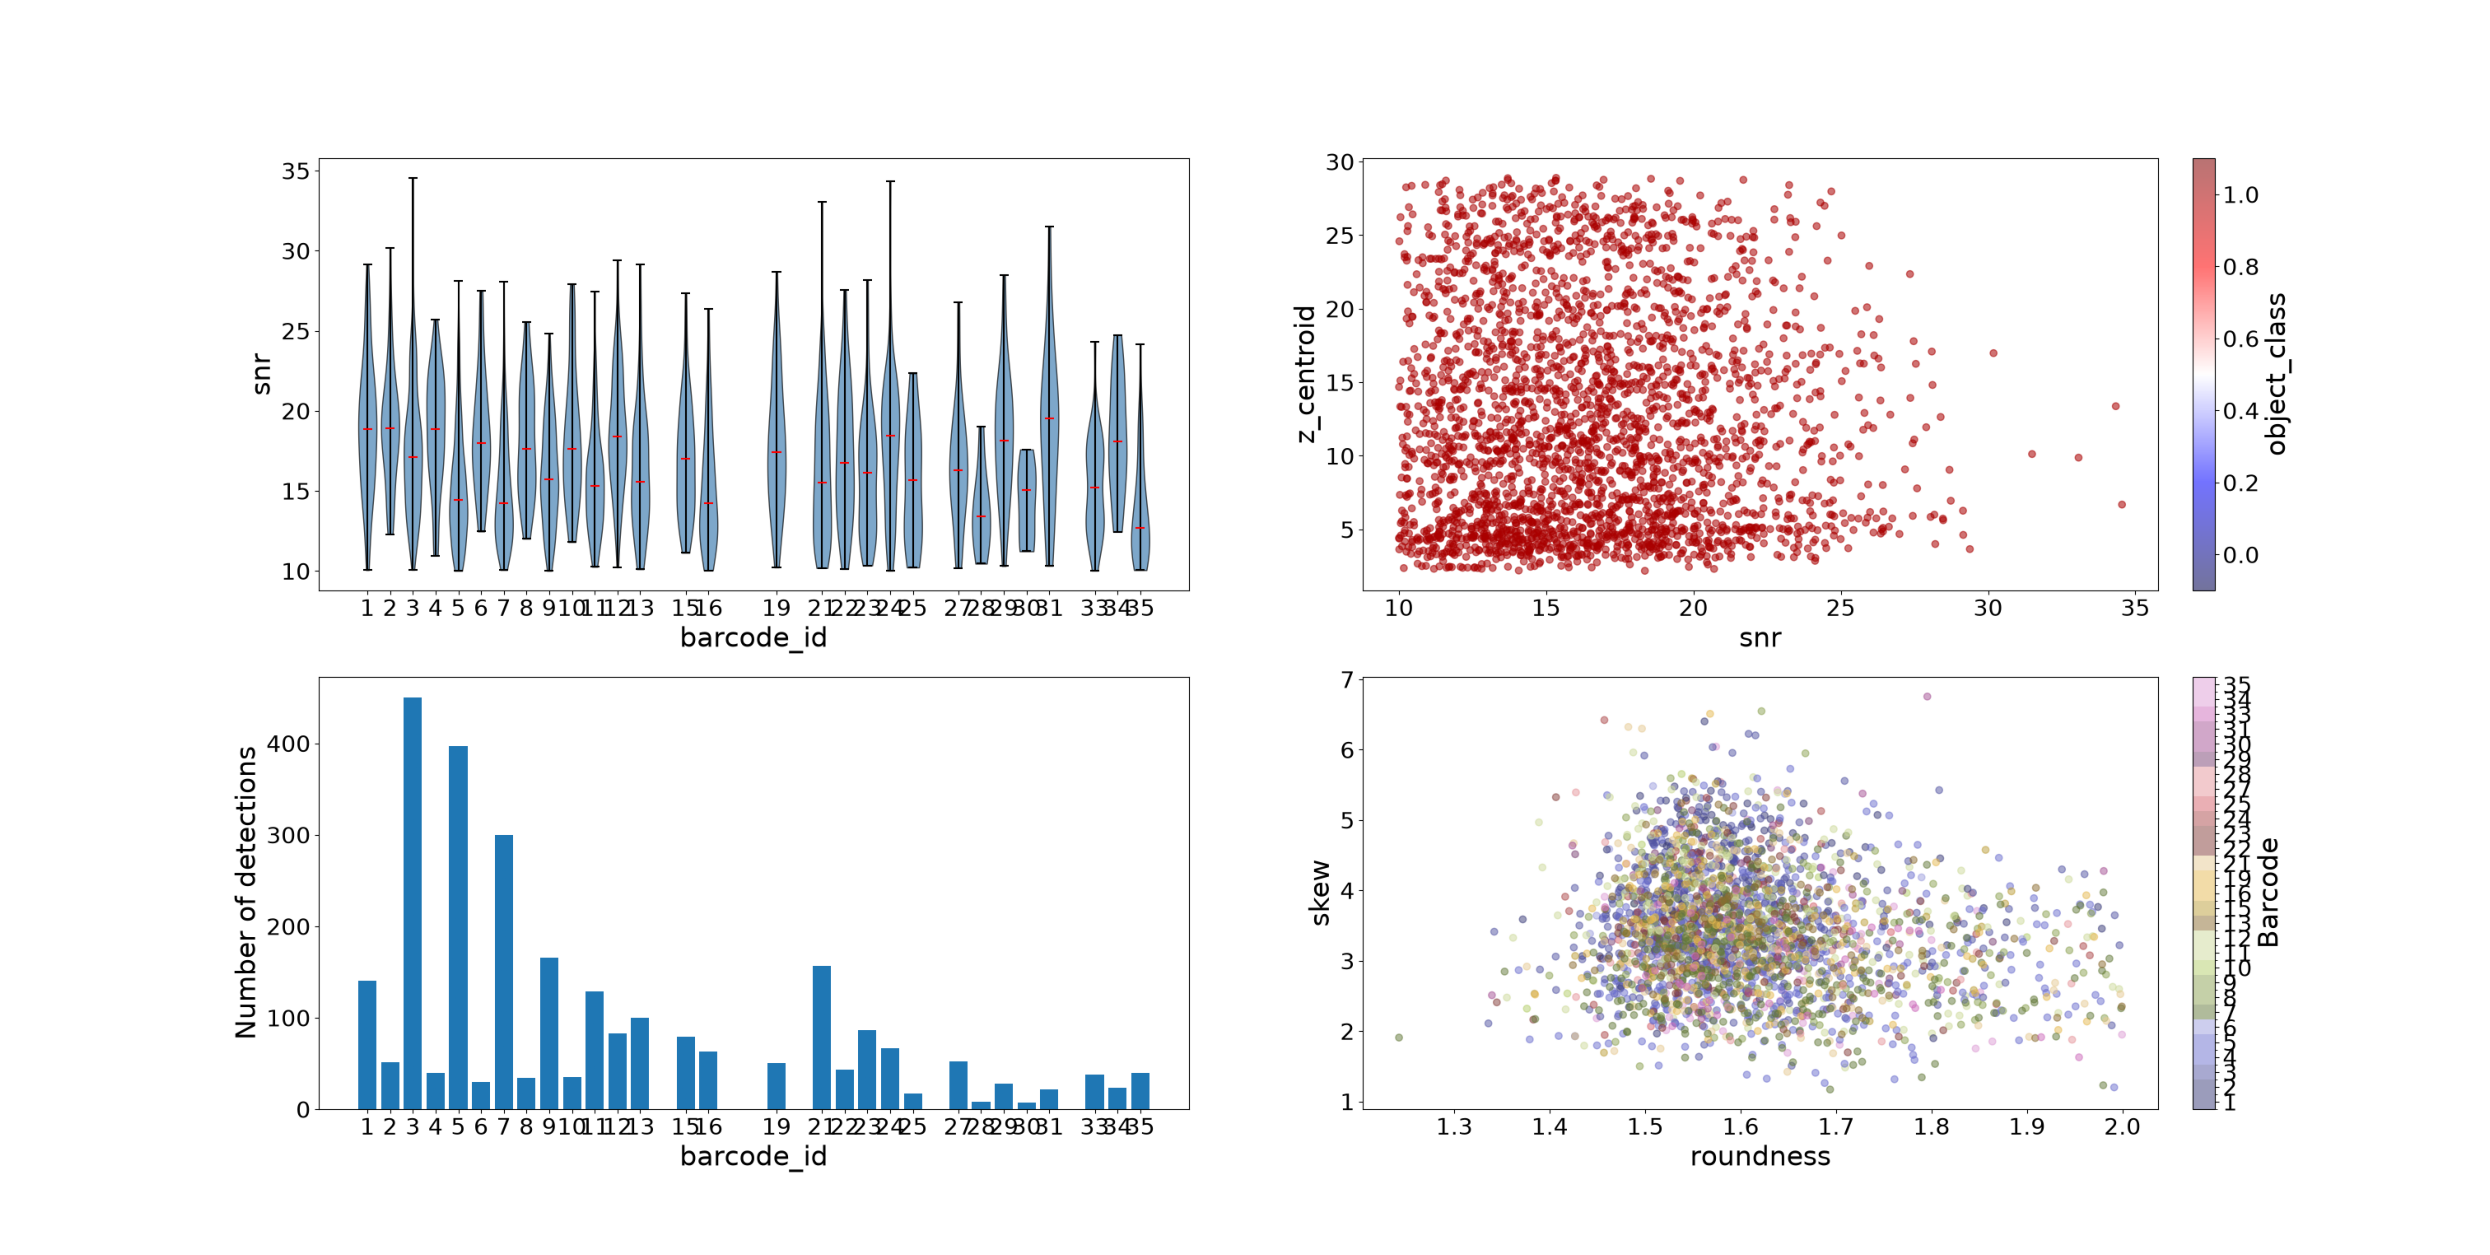

In [26]:
# Compare after filtering
intensity = f"{data_path}/Trace_3D_barcode_KDtree_ROI-22_filtered_localization_distribution_fluxes.png"
# Display the localization_distribution plots
img = mpimg.imread(intensity)
fig, ax = plt.subplots(figsize=(25, 15))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### Interpretation

## Summary

### Quality control script for localizations
| Script and options | Output |
|--------|-----------------|
| `trace_analyzer` | Single figure with 4 statistic plots |
| `-L` | localization file path |
| `-o` | Output plot file name |
| `--format` | Possible choice of format : png,svg,pdf |

### Filter localizations with `trace_filter`
| Filter | Option | When to Use |
|--------|--------|-------------|
| Filter intensity / peak | `--intensity_min` |  |
| Remove background | `--snr_min` |  |
| Min. skew | `--skew_min` | |
| Min. patch size fo each spot | `--patch_size_min` |  |
| Detection of spots classfied as object_class=1 | `--object_class_min` | |
| Max. spot pixel percentage | `--spot_pixel_percentage_max` | |
| Roundness | `--roundness_max` |  |


**Next:** [Filter barcodes](tutorial_filter_duplicate_barcodes.ipynb)